### Phase 1 - Understand the Dataset
Tasks

* Load MOS file:
* View:
* Q1 - How are naturalness scores distributed?

In [12]:
import pandas as pd 
df = pd.read_csv("../data/raw/mydata_system.csv")
df.head()

,system_ID,mean
0,sys8e5c5,1.890152
1,sys20bf9,2.485714
2,sysf9ead,4.387097
3,sysdc2ac,3.810606
4,sysbdba5,3.852273


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   system_ID  181 non-null    str    
 1   mean       181 non-null    float64
dtypes: float64(1), str(1)
memory usage: 3.0 KB


In [14]:
df["mean"].describe()

count    181.000000
mean       2.901016
std        0.770535
min        1.242857
25%        2.371324
50%        2.861111
75%        3.587838
max        4.477941
Name: mean, dtype: float64

<Axes: >

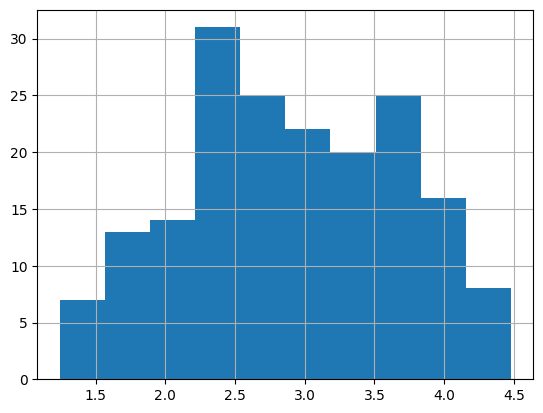

In [15]:
df["mean"].hist()

In [16]:
import sqlite3 

# create 'my_database.db' if it does not exist
conn = sqlite3.connect("../data/processed/system_data.db")

# write df to sqlite3
df.to_sql(name="sys_data", con=conn, if_exists='replace', index=False)

181

In [17]:
# load from .db

query = "select * from sys_data"

df = pd.read_sql_query(query, conn)

conn.close()

df.head()

,system_ID,mean
0,sys8e5c5,1.890152
1,sys20bf9,2.485714
2,sysf9ead,4.387097
3,sysdc2ac,3.810606
4,sysbdba5,3.852273


===============================================================================================================

### Phase 2 - Understand Audio
Notebook: 02_feature_extraction.ipynb

* Goal: Convert audio into numbers.
* Problem: The computer cannot analyze 'audio.wav' directly.
* Solution: must convert it into: <br>

| File | Duration | Pitch Std | Energy Std |
| ---- | -------- | --------- | ---------- |
| a.wav| 3.1      | 22        | 0.15       |

Task 

1. Load one audio file:
2. Get duration:
3. Get pitch variability
4. Get energy variability
5. Save results:

### Testing and learn how to extract audio to variance

In [19]:
!pip3 install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 12.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [librosa]4/15 [librosa]e]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3.14 -m pip install --upgrade pip


In [ ]:
import librosa
import numpy as np
print(librosa.version)

<module 'librosa.version' from '/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/librosa/version.py'>


In [21]:
audio_path = "/Users/mac/Acoustic-TTS-Analysis/data/raw/audio/sys0b2c1-utt0b99faf.wav"

y, sr = librosa.load(audio_path)

In [ ]:
print(y[:10]) # These numbers are the audio signal.
print(sr)  # The audio is represented by 22,050 samples every second.

[-2.6320964e-05 -8.9147870e-06  1.9747786e-06  3.1196848e-06
 -8.6775651e-07 -2.1300861e-05 -2.4254681e-05 -4.0692316e-07
  4.9177397e-06 -1.7482361e-06]
22050


In [25]:
# how long is audio
duration = librosa.get_duration(y=y, sr=sr)
print(duration)

2.1


[108.15756037 110.07119959  94.73291394  86.09249575  86.0545533
  93.46139565 150.77511195 361.94289675 179.2172782  190.27919359
 191.11492116 191.47795234 191.92452573 193.14552574 194.77949072
 217.77801575 253.04757892 246.22663696 242.7792364  240.58594233
 237.90552995 233.47339021 230.22580175 229.03640647 227.17802538
 226.8935798  223.97283579 205.11426182 200.75644271 194.81844168
 192.92963717 192.55451312 185.67642695 173.05191337 232.71902608
 267.51289991 272.78063777 276.75781278 281.09046216 292.22728601
 293.00401931 294.30893868  52.3632434  256.78636349 253.21704894
 239.47204393 238.50250734 223.30530193 202.74107272 200.36290155
 200.45385323 196.44683756 193.32252057 167.02386687 225.82143844
 229.53551305 245.31170959 253.97780515 239.63346435 173.14711886
 327.87844638 342.43490466 309.84985789 291.81701402 172.63999611
 172.81926426 172.90585184 132.30298866 107.66514926  59.90717882
  77.02156238 128.35344553 136.95745837  51.98074142  50.91534812
 268.693610

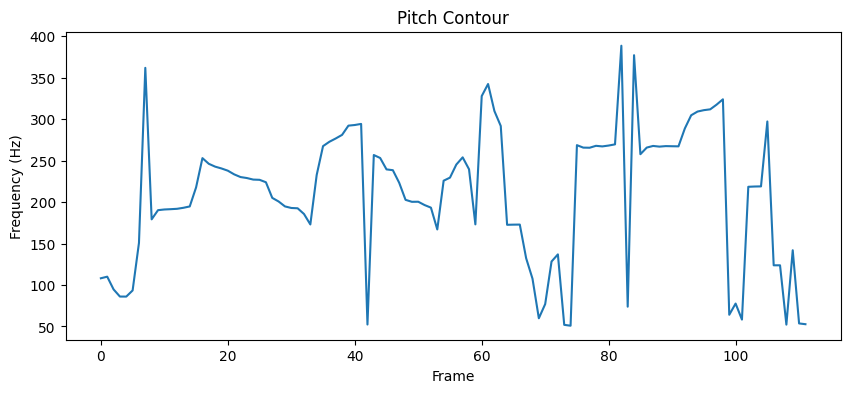

form a: 80.39320314141078


In [93]:
import numpy as np
import matplotlib.pyplot as plt

def pitch_std(path):
        y, sr = librosa.load(path=path)
        pitch = librosa.yin(
            y,
            fmin=50,
            fmax=400
        )
        print(pitch)

        pitch = pitch[np.isfinite(pitch)]

        print("Mean Pitch:", np.mean(pitch))
        print("Min Pitch:", np.min(pitch))
        print("Max Pitch:", np.max(pitch))
        print("Pitch Std:", np.std(pitch))


        plt.figure(figsize=(10,4))
        plt.plot(pitch)
        plt.title("Pitch Contour")
        plt.ylabel("Frequency (Hz)")
        plt.xlabel("Frame")
        plt.show()
        
        return np.std(pitch)

a = pitch_std("/Users/mac/Acoustic-TTS-Analysis/data/raw/audio/sys29328-utt2c5aca5.wav")
print(f"form a: {a}")




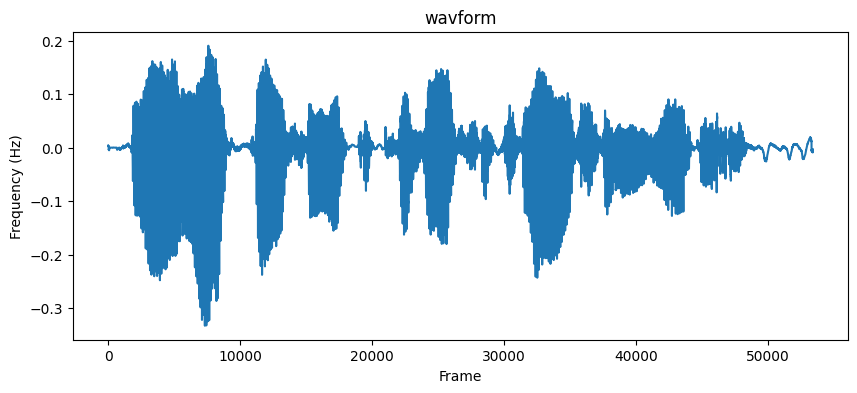

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("wavform")
plt.show()

data/raw/audio/sys67c8d-utt39d31cc.wav
3.2800907029478457


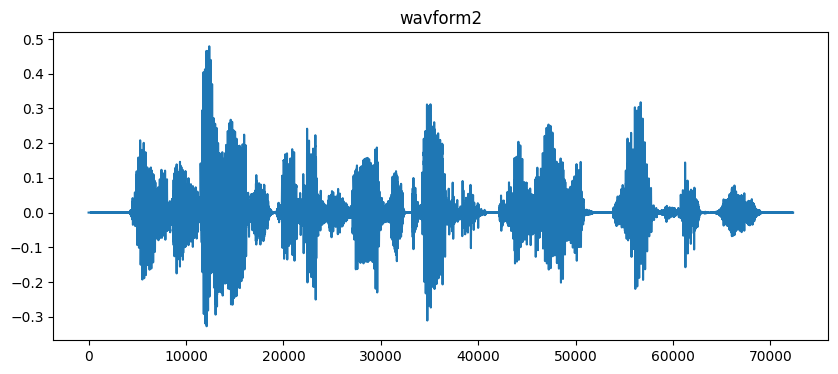

In [68]:
from pathlib import Path
import matplotlib.pyplot as plt

query = "select relative_path, absolute_path from wav_path where [index] = 6"
df = pd.read_sql_query(query, conn)
audio_path1 = df['relative_path'].iloc[0]

PROJECT_ROOT = Path.cwd().resolve().parent
full_audio_path = PROJECT_ROOT / audio_path1

print(audio_path1)
y, sr = librosa.load(full_audio_path)
duration = librosa.get_duration(y=y, sr=sr)
print(duration)

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("wavform2")
plt.show()


In [45]:
### dinamically load file path of *.wav to data base for iteration
import pandas as pd
from pathlib import Path
import sqlite3

# create 'my_database.db' if it does not exist
conn = sqlite3.connect("../data/processed/system_data.db")

PROJECT_ROOT = Path.cwd().resolve().parent

RAW_DIR = PROJECT_ROOT /"data/raw/audio"

wav_file = list(RAW_DIR.glob('*.wav'))

dataset_record = []
for file_path in wav_file:
    record = {
        "file_name": file_path.name,
        "relative_path": str(file_path.relative_to(PROJECT_ROOT)),
        "absolute_path": str(file_path.resolve())
    }
    dataset_record = [record] + dataset_record


df = pd.DataFrame(dataset_record)
df.to_sql(name="wav_path", con=conn, if_exists='replace', index=True)

df.head()

,file_name,relative_path,absolute_path
0,sysc382e-uttcbd8617.wav,data/raw/audio/sysc382e-uttcbd8617.wav,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...
1,sys05205-utta21631b.wav,data/raw/audio/sys05205-utta21631b.wav,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...
2,sys9e6de-utt9543789.wav,data/raw/audio/sys9e6de-utt9543789.wav,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...
3,syseba96-utt04ec954.wav,data/raw/audio/syseba96-utt04ec954.wav,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...
4,sys94e9f-utt0c88a0a.wav,data/raw/audio/sys94e9f-utt0c88a0a.wav,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...


In [ ]:
''' * Strategy
    1. read relative_path from wav_path system_data.db
    2. iterate index 
    3. extract y, sr from wav
    4. calculate duration
    5. table 'wav_attribute' key: file, duration, Pitch Std, Energy Std
'''

import pandas as pd
from pathlib import Path
import sqlite3
import librosa
import numpy as np

conn = sqlite3.connect("../data/processed/system_data.db")
query = "select relative_path, absolute_path from wav_path"

df_raw_path = pd.read_sql_query(query, conn)

df_clean_path = df_raw_path['absolute_path'].iloc()

df = []
for path_to_db in df_clean_path:
    # df_clean_path = [temp_path] + df_clean_path
    y, sr = librosa.load(path=path_to_db)
    duration = librosa.get_duration(y=y, sr=sr)
    attribute = {
        'file': path_to_db,
        'duration': duration
    }

    df = [attribute] + df

df_converted = pd.DataFrame(df)
df_converted.to_sql(name="wav_attribute", con=conn, if_exists='replace', index=True)

df_converted.head()


===============================================================================================================

### Phase 3 — Merge Everything
Notebook: 03_analysis.ipynb

* Combine: MOS scores+ Acoustic feature

MOS

| system | MOS | 
| ---- | -------- |
| sys1| 4.5      | 

Feature

| system | pitch_std | 
| ---- | -------- |
| sys1| 28     | 

Merge:

| system |  MOS | pitch_std | 
| ---- | -------- | -------- | 
| sys1| 4.5 | 28     | 

In [2]:
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
import sqlite3

In [10]:
'''duration function'''
'''Pitch Variability Function'''
'''Energy Variability Function'''

class Wav:
    '''sdfsdfsdfsfas'''

    def get_duration(self, path):
        y, sr = librosa.load(path=path)
        return librosa.get_duration(y=y, sr=sr)

    def get_pitch_std(self, path):
        y, sr = librosa.load(path=path)
        pitch = librosa.yin(
            y,
            fmin=50,
            fmax=400
        )
        pitch = pitch[np.isfinite(pitch)]
        return np.std(pitch)

    def get_energy_std(self, path):
        y, sr = librosa.load(path=path)
        frame_energy = librosa.feature.rms(y=y)[0]
        return np.std(frame_energy)

    def get_path(self, query, path):
        conn = sqlite3.connect(path)
        df_raw_path = pd.read_sql_query(query, conn)
        df_clean_path = df_raw_path['absolute_path'].iloc()
        return df_clean_path

    def save_to_database(self, df, path_to_db):
        conn = sqlite3.connect(path_to_db)
        self.df_varibility = pd.DataFrame(df)
        self.df_varibility.to_sql(name="wav_attribute", con=conn, if_exists='replace', index=True)
        self.df_varibility.head()
        print("sucessfuly save to database!")

if __name__ == "__main__":
    wav = Wav()
    df_audio_path = wav.get_path("select absolute_path from wav_path", "../data/processed/system_data.db")
    
    df = []
    for path in df_audio_path:
        attribute = {
            'file': path,
            'duration': wav.get_duration(path=path),
            'pitch_std': wav.get_pitch_std(path=path),
            'energy_std': wav.get_energy_std(path=path)
        }
        df = [attribute] + df

    wav.save_to_database(df, "../data/processed/system_data.db")

sucessfuly save to database!


#### Strategy for ELT/ETL
* read data from txt to variable
* convert variable to pd.DataFrame (* 3 file)
* df.to_sql new table 
* work on qurey.sql -> drop duplicate 
* compare file name with file name in table wav_attribute 
* create MOS attribute to wav_attribute 
* analyze nul MOS but not drop for null 

In [22]:
import pandas as pd

df = pd.read_csv('/Users/mac/Acoustic-TTS-Analysis/data/raw/sets/val_mos_list.txt', sep=',', header=None, names=['file', 'MOS'])

df.head()




,file,MOS
0,sys64e2f-utt8c3d2b2.wav,4.000
1,sys64e2f-utt3a1aedf.wav,3.625
2,sys64e2f-utt549b7c4.wav,4.125
3,sys64e2f-utt0c4d719.wav,3.750
4,sys64e2f-utt4eddf90.wav,3.625


In [23]:
df.describe()

,MOS
count,1066.000000
mean,2.902791
std,0.909266
min,1.000000
25%,2.250000
50%,2.875000
75%,3.625000
max,4.875000


array([[<Axes: title={'center': 'MOS'}>]], dtype=object)

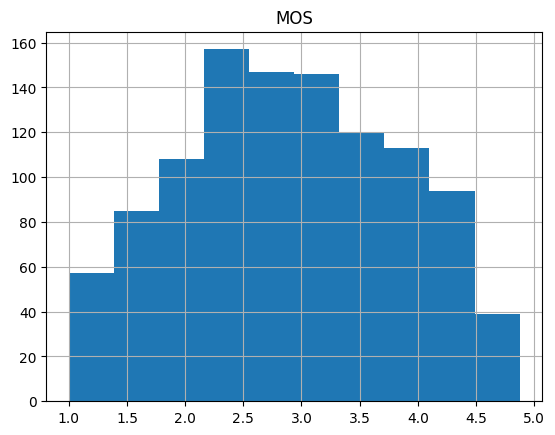

In [24]:
df.hist()

In [25]:
import sqlite3

path = "/Users/mac/Acoustic-TTS-Analysis/data/processed/system_data.db"
conn = sqlite3.connect(path)

df.to_sql(name='load_raw_mos', con=conn, if_exists='append', index=True)

1066

In [26]:
import sqlite3
import pandas as pd
from pathlib import Path

conn = sqlite3.connect("../data/processed/system_data.db")

df = pd.read_sql_query(
    "SELECT * FROM wav_attribute",
    conn
)

df["filename"] = df["file"].apply(
    lambda p: Path(p).name
)

In [27]:
df.head()

,index,file,duration,pitch_std,energy_std,filename
0,0,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.421270,53.197731,0.026181,sysa6294-utt1044c15.wav
1,1,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.745215,84.514417,0.029952,sys47c67-utt3074e9f.wav
2,2,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.420000,29.023627,0.031069,sysec937-uttc43794d.wav
3,3,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,3.100000,63.478065,0.026238,syseccd8-utt5b0d60b.wav
4,4,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.435011,60.879089,0.026401,sys2a001-utte8e0110.wav


In [28]:
df.to_sql(
    "wav_attribute",
    conn,
    if_exists="replace",
    index=False
)

3382

### Day 5
* purpose: Create visualizations that answer your research questions.

step: 
* Create Final Analysis Table (query.db)
* Load into Pandas
* MOS Distribution (RQ1)
* Pitch vs MOS
* Energy vs MOS
* Duration vs MOS
* Correlation Matrix (Most Important)

In [29]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/processed/system_data.db")
query = "select * from wav_analysis"

df = pd.read_sql_query(query, con=conn)

df.head()

,file,duration,pitch_std,energy_std,MOS
0,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.421270,53.197731,0.026181,3.625
1,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.745215,84.514417,0.029952,3.125
2,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,2.420000,29.023627,0.031069,2.625
3,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,3.100000,63.478065,0.026238,3.625
4,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.435011,60.879089,0.026401,4.375


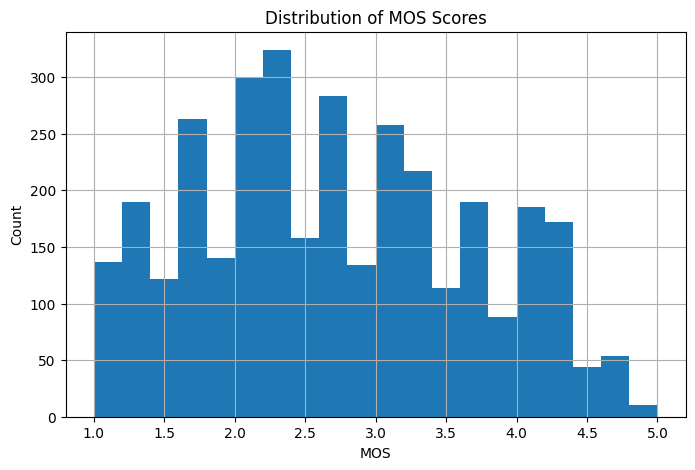

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["MOS"].hist(bins=20)

plt.title("Distribution of MOS Scores")
plt.xlabel("MOS")
plt.ylabel("Count")

plt.show()

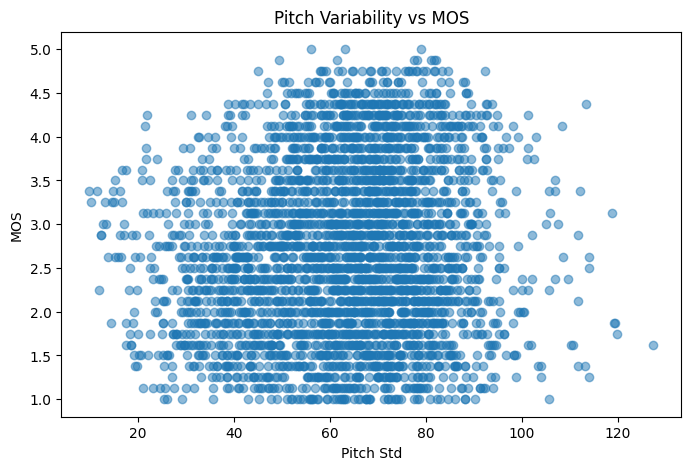

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["pitch_std"],
    df["MOS"],
    alpha=0.5
)

plt.xlabel("Pitch Std")
plt.ylabel("MOS")
plt.title("Pitch Variability vs MOS")

plt.show()

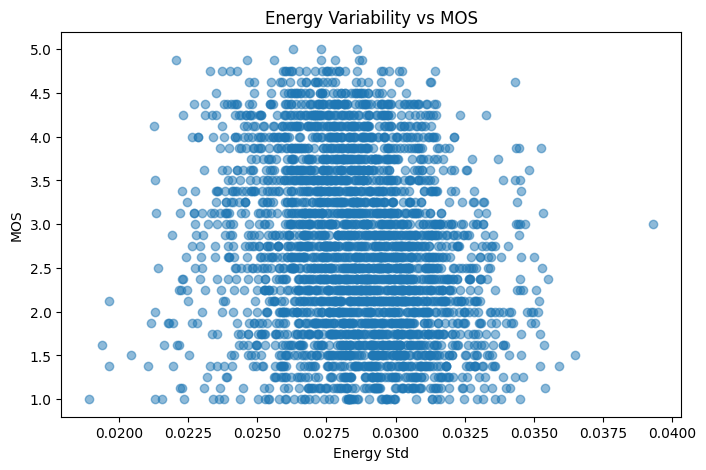

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["energy_std"],
    df["MOS"],
    alpha=0.5
)

plt.xlabel("Energy Std")
plt.ylabel("MOS")
plt.title("Energy Variability vs MOS")

plt.show()

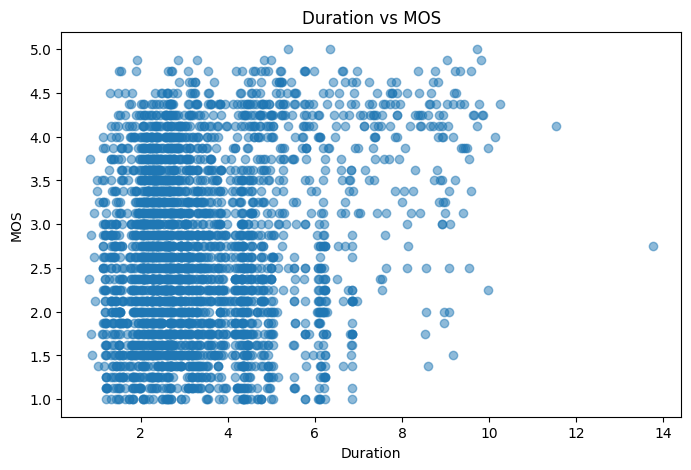

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["duration"],
    df["MOS"],
    alpha=0.5
)

plt.xlabel("Duration")
plt.ylabel("MOS")
plt.title("Duration vs MOS")

plt.show()

In [35]:
corr = df[
    [
        "duration",
        "pitch_std",
        "energy_std",
        "MOS"
    ]
].corr()

corr

,duration,pitch_std,energy_std,MOS
duration,1.000000,0.030098,-0.074465,0.205489
pitch_std,0.030098,1.000000,0.285037,0.101419
energy_std,-0.074465,0.285037,1.000000,-0.187781
MOS,0.205489,0.101419,-0.187781,1.000000


### day6

In [36]:
df["MOS"].describe()

count    3382.000000
mean        2.702025
std         0.963931
min         1.000000
25%         1.875000
50%         2.625000
75%         3.500000
max         5.000000
Name: MOS, dtype: float64

<Axes: >

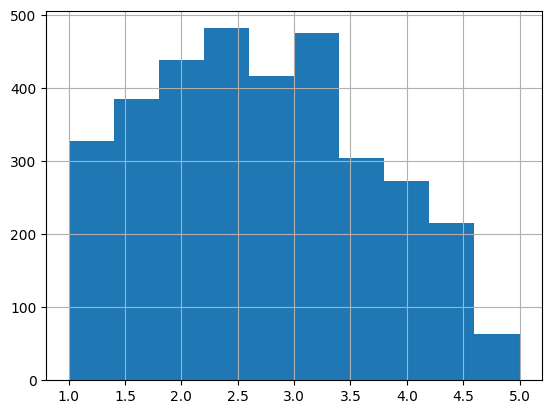

In [37]:
df["MOS"].hist()

In [38]:
df["pitch_std"].corr(df["MOS"])

np.float64(0.10141863951849428)

In [39]:
df["energy_std"].corr(df["MOS"])

np.float64(-0.18778064378843717)

In [40]:
df["duration"].corr(df["MOS"])

np.float64(0.20548945489234352)

In [41]:
corr = df[
    [
        "duration",
        "pitch_std",
        "energy_std",
        "MOS"
    ]
].corr()

corr

,duration,pitch_std,energy_std,MOS
duration,1.000000,0.030098,-0.074465,0.205489
pitch_std,0.030098,1.000000,0.285037,0.101419
energy_std,-0.074465,0.285037,1.000000,-0.187781
MOS,0.205489,0.101419,-0.187781,1.000000


In [42]:
df.nlargest(
    10,
    "MOS"
)[
    ["file","MOS","pitch_std","energy_std"]
]

,file,MOS,pitch_std,energy_std
302,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,5.000,63.270524,0.028607
1053,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,5.000,56.130970,0.027311
3139,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,5.000,78.937048,0.026307
251,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,81.203632,0.028695
1014,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,61.601921,0.022080
1327,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,77.521687,0.027290
1420,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,78.118402,0.025610
1458,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,49.486224,0.024620
2650,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,82.175071,0.028773
2771,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,4.875,81.805837,0.027798


In [43]:
df.nsmallest(
    10,
    "MOS"
)[
    ["file","MOS","pitch_std","energy_std"]
]

,file,MOS,pitch_std,energy_std
5,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,78.711094,0.026588
21,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,63.431022,0.030748
42,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,49.010478,0.026004
61,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,67.519503,0.028345
146,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,73.832924,0.028326
180,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,61.852669,0.026046
192,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,66.331045,0.028392
272,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,80.900491,0.029678
304,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,84.723825,0.031507
307,/Users/mac/Acoustic-TTS-Analysis/data/raw/audi...,1.0,29.232187,0.027073


### Answering Research Question
* RQ1: How are naturalness scores distributed?
* hint: MOS scores range from X to Y, with an average of Z.


* RQ2: Which acoustic features are most strongly associated with naturalness?
* hint: Pitch variability shows the strongest positive relationship with MOS.

* RQ3: How do high-scoring and low-scoring systems differ?
* hint: Higher rated systems tend to exhibit greater pitch variation. 

### What You Need to Learn

| Day 1 | Day 2 | Day 3 | Day 4 | Day 5 | Day 6 |
| --- | --- | --- | --- | --- | --- | 
| Pandas | Librosa | Feature extraction | Pandas merge | Visualization | Correlation | Report writing | 
| read_csv() | load() | pitch | merge()  | hist() | corr() |
| head() | get_duration()| energy  |  | scatter() |  |
| describe() | get_patch() | MOS |  |  |  |
|  | get_energy() | duration |  |  |  |
| processed | process | pending | pending | pending | pending | 

### Work flow
```
.wav files
      ↓
Extract Features
      ↓
Features.db (sqlite3)
      ↓
Merge with MOS
      ↓
Charts + Correlations
      ↓
Answer 3 Research Questions
```